In [3]:
import pandas as pd
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS TRATADOS ---

# Nomes dos arquivos que foram salvos anteriormente
pib_path = '../dados/pib_tratado.pkl'
desemprego_path = '../dados/desemprego_tratado.pkl'

try:
    # Carregar os DataFrames a partir dos arquivos .pkl
    df_pib = pd.read_pickle(pib_path)
    df_desemprego = pd.read_pickle(desemprego_path)

    print("--- Dados do PIB carregados (head) ---")
    print(df_pib.head())
    print("\n" + "="*50 + "\n")
    
    print("--- Dados de Desemprego carregados (head) ---")
    print(df_desemprego.head())
    print("\n" + "="*50 + "\n")

except FileNotFoundError as e:
    print(f"Erro: Arquivo não encontrado. Verifique se os arquivos '{pib_path}' e '{desemprego_path}' estão no mesmo diretório que este notebook.")
    print(f"Detalhe do erro: {e}")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao" )
# --- 2. UNIFICAÇÃO DOS DADOS ---

# Juntar os dois DataFrames pelo índice (que é a data)
# 'inner' join garante que teremos apenas as datas para as quais ambos os dados existem
df_final = df_desemprego.join(df_pib, how='inner')

# Renomear a coluna 'desemprego' para 'u_t' para seguir a notação da documentação
df_final.rename(columns={'desemprego': 'u_t'}, inplace=True)


# --- 3. CRIAÇÃO DAS VARIÁVEIS DE ANÁLISE FINAIS ---

# A documentação pede a variável Δu_t (variação do desemprego)
# Δu_t = u_t - u_{t-1}
df_final['delta_u_t'] = df_final['u_t'].diff()


# --- 4. VERIFICAÇÃO FINAL ---

print("--- DataFrame Final Unificado (head) ---")
print(df_final.head())
print("\n" + "--- DataFrame Final Unificado (tail) ---")
print(df_final.tail())
print("\n" + "--- Informações do DataFrame Final ---")

# Verificar a presença de dados nulos. A primeira linha de 'delta_u_t' e 'crescimento_pib' será NaN, o que é esperado.
# Vamos remover essa primeira linha para a análise.
df_final.dropna(inplace=True)

df_final.info()

print("\n" + "--- Verificação de Nulos Após Limpeza ---")
print(df_final.isnull().sum())

print("\n" + "--- DataFrame pronto para a análise econométrica ---")
print(df_final.head())

--- Dados do PIB carregados (head) ---
                    pib     ln_pib  crescimento_pib
data                                               
1996-03-31  175461.6360  12.075176              NaN
1996-06-30  177540.3069  12.086953         1.177724
1996-09-30  184101.2613  12.123241         3.628828
1996-12-31  182347.0228  12.113667        -0.957435
1997-03-31  184308.8135  12.124368         1.070109


--- Dados de Desemprego carregados (head) ---
            desemprego metodologia
Data                              
1994-03-31    6.056667  PME_Antiga
1994-06-30    5.736667  PME_Antiga
1994-09-30    5.646667  PME_Antiga
1994-12-31    4.306667  PME_Antiga
1995-03-31    4.640000  PME_Antiga


--- DataFrame Final Unificado (head) ---
                 u_t metodologia          pib     ln_pib  crescimento_pib  \
1996-03-31  6.170000  PME_Antiga  175461.6360  12.075176              NaN   
1996-06-30  6.366667  PME_Antiga  177540.3069  12.086953         1.177724   
1996-09-30  5.856667  PME_Anti

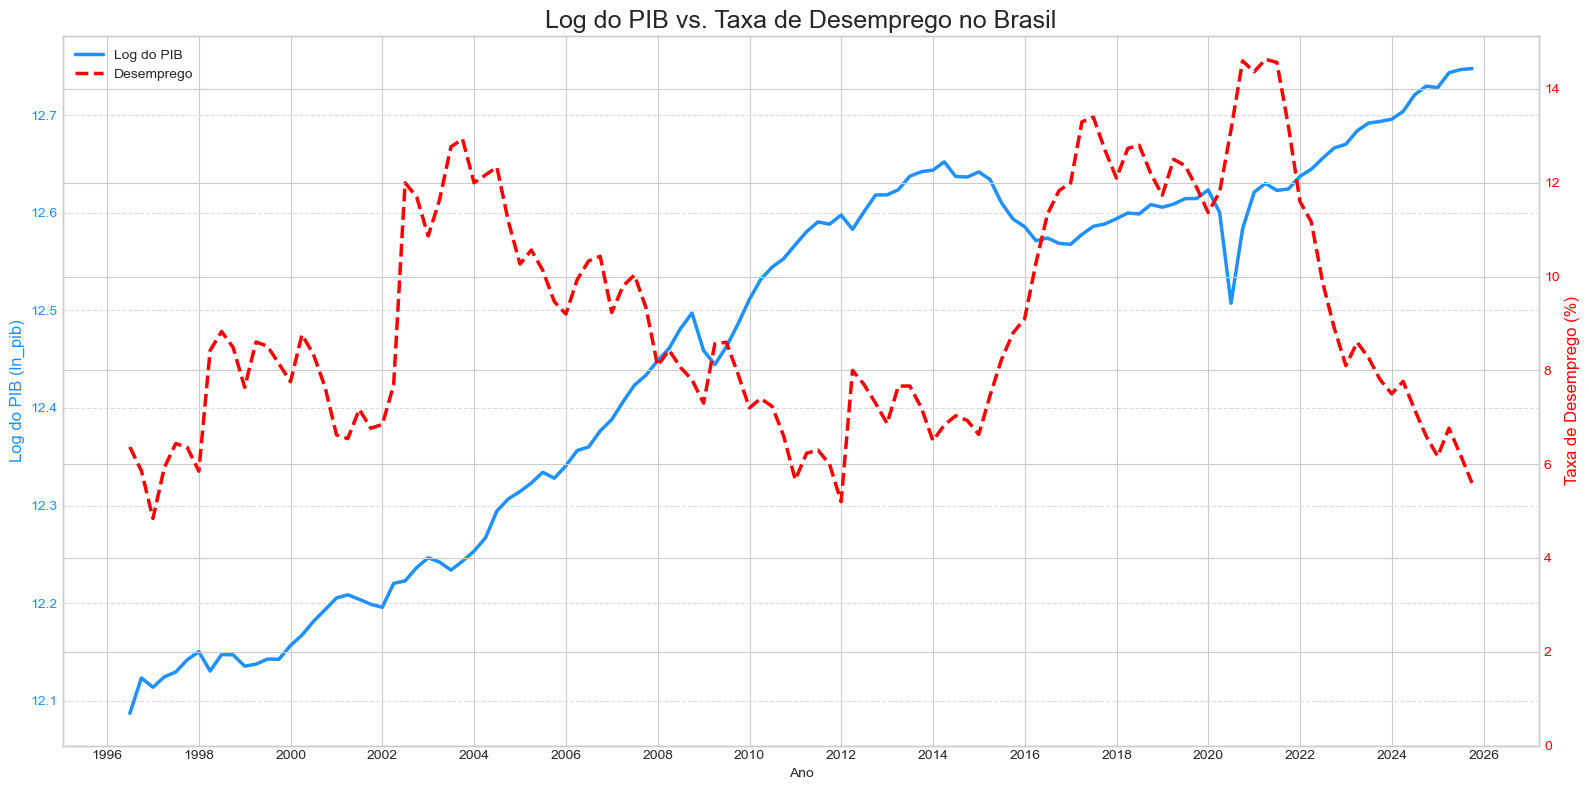

=> Figura salva: fig_01_pib_desemprego_eixo_duplo.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Configurações de Estilo (Opcional) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# --- Criação do Gráfico com Dois Eixos Y ---

fig, ax1 = plt.subplots()

# Título do Gráfico
ax1.set_title('Log do PIB vs. Taxa de Desemprego no Brasil', fontsize=18)

# --- Eixo 1 (Esquerda): Log do PIB ---
color1 = 'dodgerblue'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Log do PIB (ln_pib)', color=color1, fontsize=12)
ax1.plot(df_final.index, df_final['ln_pib'], color=color1, linewidth=2.5, label='Log do PIB')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Eixo 2 (Direita): Taxa de Desemprego ---
ax2 = ax1.twinx()  # Cria um segundo eixo que compartilha o mesmo eixo X
color2 = 'red'
ax2.set_ylabel('Taxa de Desemprego (%)', color=color2, fontsize=12)
ax2.plot(df_final.index, df_final['u_t'], color=color2, linewidth=2.5, linestyle='--', label='Desemprego')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0) # Garante que a taxa de desemprego comece em 0


# --- Legenda Combinada ---
# Pega as linhas e os rótulos de ambos os eixos para criar uma única legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


# --- Formatação do Eixo X (Data) ---
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)


# --- Finalização ---
fig.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.savefig('../figuras/fase1_tratamento/fig_01_pib_desemprego_eixo_duplo.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_01_pib_desemprego_eixo_duplo.png')


In [5]:
# Célula para Testes de Estacionariedade (Raiz Unitária) - VERSÃO COM VALORES CRÍTICOS
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Ignorar avisos do teste KPSS para uma saída mais limpa
warnings.filterwarnings('ignore', category=UserWarning)

# --- CONFIGURAÇÃO ---
df_testes = df_final

variaveis_para_testar = {
    'u_t': 'Desemprego (u_t)',
    'ln_pib': 'Log do PIB (ln_pib_t)',
    'delta_u_t': 'Variação do Desemprego (Δu_t)',
    'crescimento_pib': 'Crescimento do PIB (crescimento_pib_t)'
}

# --- EXECUÇÃO DOS TESTES ---

print("="*60)
print("Executando Testes de Estacionariedade (com Valores Críticos)")
print("="*60)
print("Objetivo esperado:")
print("- Séries em NÍVEL (Desemprego, Log do PIB): NÃO ESTACIONÁRIAS (I(1))")
print("- Séries em DIFERENÇA (Variação Desemprego, Crescimento PIB): ESTACIONÁRIAS (I(0))\n")


for nome_coluna, nome_bonito in variaveis_para_testar.items():
    
    serie = df_testes[nome_coluna]
    
    print(f"\n--- Testando a variável: {nome_bonito} ---\n")
    
    # 1. Teste Augmented Dickey-Fuller (ADF)
    print("1. Teste ADF (Augmented Dickey-Fuller)")
    # H₀: A série TEM uma raiz unitária (não é estacionária).
    
    resultado_adf = adfuller(serie)
    estatistica_adf = resultado_adf[0]
    p_valor_adf = resultado_adf[1]
    valores_criticos_adf = resultado_adf[4]
    
    print(f"   - Estatística do Teste: {estatistica_adf:.4f}")
    print(f"   - P-valor: {p_valor_adf:.4f}")
    print("   - Valores Críticos (Estatística Limite):")
    for key, value in valores_criticos_adf.items():
        print(f'     - {key}: {value:.4f}')

    # A conclusão é baseada na estatística de teste ser MAIS NEGATIVA que os valores críticos.
    if p_valor_adf < 0.05:
        print("   - Conclusão: Rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.")
    else:
        print("   - Conclusão: Não rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.")
        
    print("-" * 25)

    # 2. Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
    print("2. Teste KPSS")
    # H₀: A série É estacionária.
    
    resultado_kpss = kpss(serie, regression='ct', nlags="auto")
    estatistica_kpss = resultado_kpss[0]
    p_valor_kpss = resultado_kpss[1]
    valores_criticos_kpss = resultado_kpss[3]
    
    print(f"   - Estatística do Teste: {estatistica_kpss:.4f}")
    print(f"   - P-valor: {p_valor_kpss:.4f}")
    print("   - Valores Críticos (Estatística Limite):")
    for key, value in valores_criticos_kpss.items():
        print(f'     - {key}: {value:.4f}')
        
    # A conclusão é baseada na estatística de teste ser MENOR que os valores críticos.
    if p_valor_kpss < 0.05:
        print("   - Conclusão: Rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.")
    else:
        print("   - Conclusão: Não rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.")
        
    print("\n" + "="*50)

Executando Testes de Estacionariedade (com Valores Críticos)
Objetivo esperado:
- Séries em NÍVEL (Desemprego, Log do PIB): NÃO ESTACIONÁRIAS (I(1))
- Séries em DIFERENÇA (Variação Desemprego, Crescimento PIB): ESTACIONÁRIAS (I(0))


--- Testando a variável: Desemprego (u_t) ---

1. Teste ADF (Augmented Dickey-Fuller)
   - Estatística do Teste: -2.0510
   - P-valor: 0.2647
   - Valores Críticos (Estatística Limite):
     - 1%: -3.4907
     - 5%: -2.8880
     - 10%: -2.5809
   - Conclusão: Não rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.
-------------------------
2. Teste KPSS
   - Estatística do Teste: 0.1006
   - P-valor: 0.1000
   - Valores Críticos (Estatística Limite):
     - 10%: 0.1190
     - 5%: 0.1460
     - 2.5%: 0.1760
     - 1%: 0.2160
   - Conclusão: Não rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.


--- Testando a variável: Log do PIB (ln_pib_t) ---

1. Teste ADF (Augmen

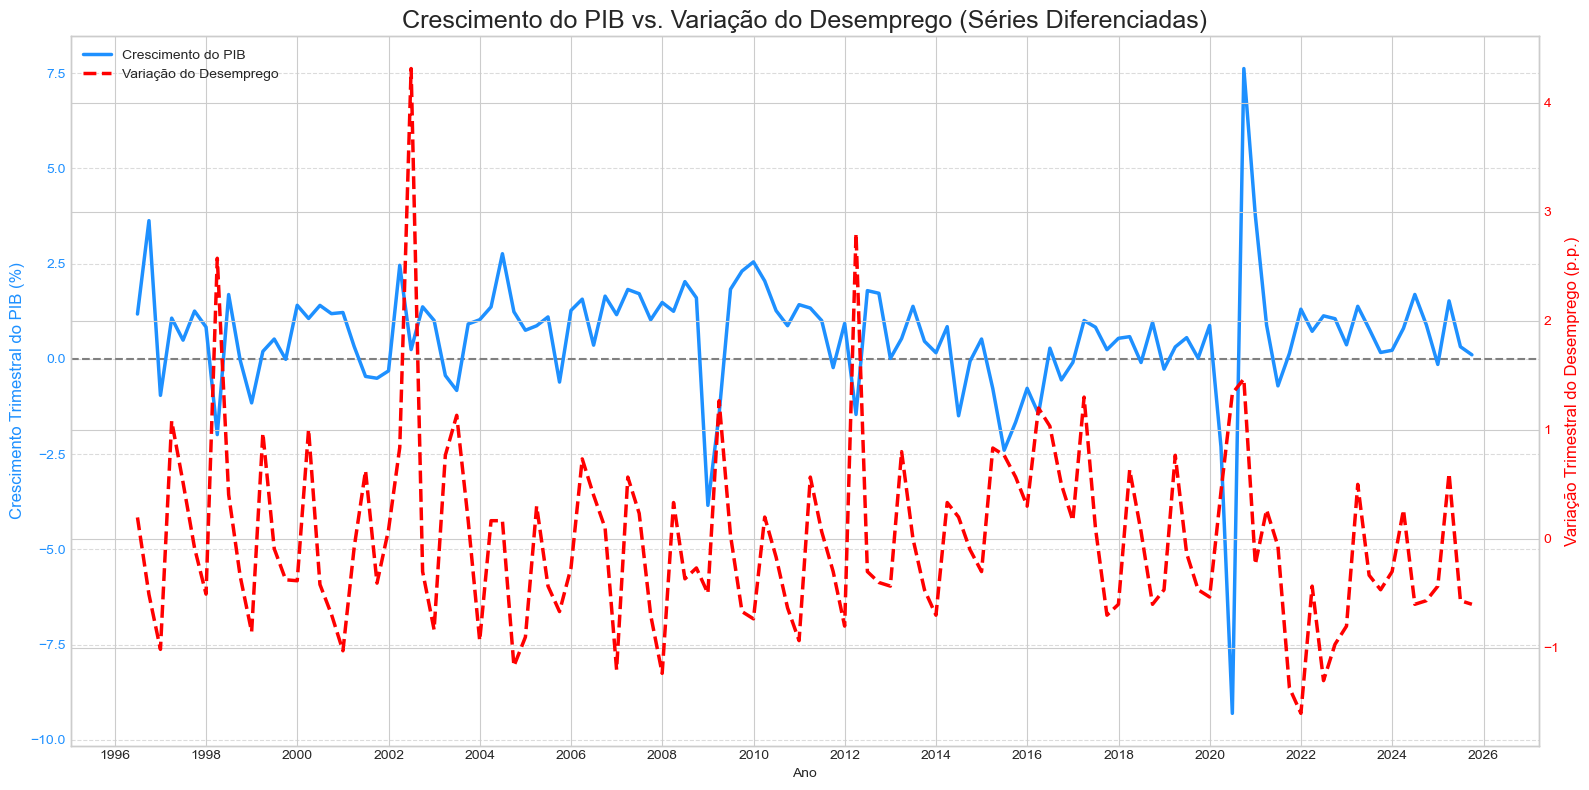

In [6]:
# Célula para o Gráfico das Séries em Primeira Diferença



# --- Configurações de Estilo (Opcional) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# --- Criação do Gráfico com Dois Eixos Y ---

fig, ax1 = plt.subplots()

# Título do Gráfico
ax1.set_title('Crescimento do PIB vs. Variação do Desemprego (Séries Diferenciadas)', fontsize=18)

# Adiciona uma linha horizontal em y=0 para referência visual da média
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1.5)

# --- Eixo 1 (Esquerda): Crescimento do PIB ---
color1 = 'dodgerblue'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Crescimento Trimestral do PIB (%)', color=color1, fontsize=12)
ax1.plot(df_final.index, df_final['crescimento_pib'], color=color1, linewidth=2.5, label='Crescimento do PIB')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Eixo 2 (Direita): Variação da Taxa de Desemprego ---
ax2 = ax1.twinx()  # Cria um segundo eixo que compartilha o mesmo eixo X
color2 = 'red'
ax2.set_ylabel('Variação Trimestral do Desemprego (p.p.)', color=color2, fontsize=12)
ax2.plot(df_final.index, df_final['delta_u_t'], color=color2, linewidth=2.5, linestyle='--', label='Variação do Desemprego')
ax2.tick_params(axis='y', labelcolor=color2)


# --- Legenda Combinada ---
# Pega as linhas e os rótulos de ambos os eixos para criar uma única legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


# --- Formatação do Eixo X (Data) ---
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)


# --- Finalização ---
fig.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()

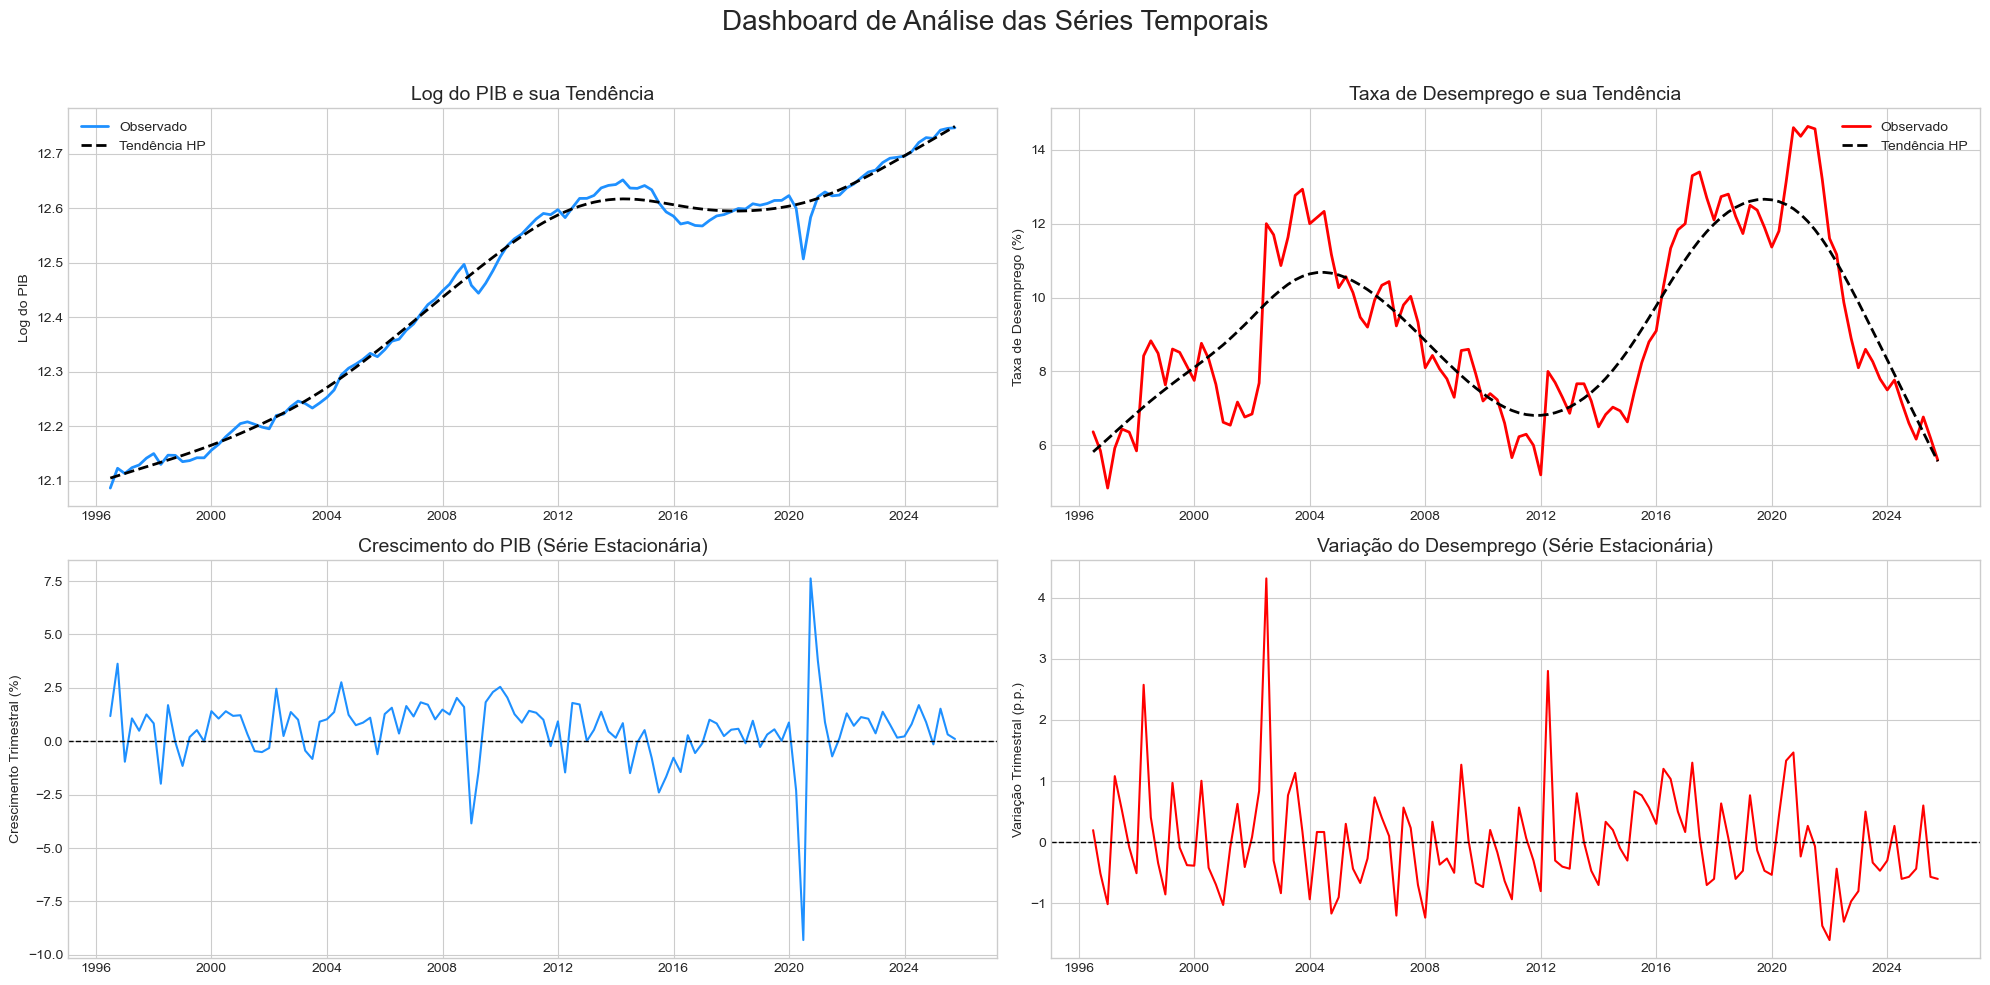

=> Figura salva: fig_02_hp_filter_dashboard.png


In [7]:
# Célula para o Dashboard de Análise Visual (Originais, Tendência e Diferenciadas)

from statsmodels.tsa.filters.hp_filter import hpfilter

# --- 1. PREPARAÇÃO: EXTRAIR TENDÊNCIA COM FILTRO HP ---

# O lambda=1600 é o valor padrão e recomendado para dados trimestrais.
pib_ciclo, pib_tendencia = hpfilter(df_final['ln_pib'], lamb=1600)
desemprego_ciclo, desemprego_tendencia = hpfilter(df_final['u_t'], lamb=1600)

# Adicionar as novas séries ao dataframe para facilitar o acesso
df_final['pib_tendencia_hp'] = pib_tendencia
df_final['desemprego_tendencia_hp'] = desemprego_tendencia


# --- 2. CRIAÇÃO DOS GRÁFICOS (GRID 2x2) ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(20, 10)) # 2 linhas, 2 colunas
fig.suptitle('Dashboard de Análise das Séries Temporais', fontsize=20)


# --- Gráfico 1 (Superior Esquerdo): PIB e Tendência ---
ax = axes[0, 0]
ax.plot(df_final.index, df_final['ln_pib'], label='Observado', color='dodgerblue', linewidth=2)
ax.plot(df_final.index, df_final['pib_tendencia_hp'], label='Tendência HP', color='black', linestyle='--', linewidth=2)
ax.set_title('Log do PIB e sua Tendência', fontsize=14)
ax.set_ylabel('Log do PIB')
ax.legend()
ax.grid(True)


# --- Gráfico 2 (Superior Direito): Desemprego e Tendência ---
ax = axes[0, 1]
ax.plot(df_final.index, df_final['u_t'], label='Observado', color='red', linewidth=2)
ax.plot(df_final.index, df_final['desemprego_tendencia_hp'], label='Tendência HP', color='black', linestyle='--', linewidth=2)
ax.set_title('Taxa de Desemprego e sua Tendência', fontsize=14)
ax.set_ylabel('Taxa de Desemprego (%)')
ax.legend()
ax.grid(True)


# --- Gráfico 3 (Inferior Esquerdo): Crescimento do PIB (Diferenciado) ---
ax = axes[1, 0]
ax.plot(df_final.index, df_final['crescimento_pib'], color='dodgerblue')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Crescimento do PIB (Série Estacionária)', fontsize=14)
ax.set_ylabel('Crescimento Trimestral (%)')
ax.grid(True)


# --- Gráfico 4 (Inferior Direito): Variação do Desemprego (Diferenciado) ---
ax = axes[1, 1]
ax.plot(df_final.index, df_final['delta_u_t'], color='red')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Variação do Desemprego (Série Estacionária)', fontsize=14)
ax.set_ylabel('Variação Trimestral (p.p.)')
ax.grid(True)


# --- Ajustes Finais ---
# Ajusta o formato da data em todos os eixos
for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.set_major_locator(mdates.YearLocator(4)) # Marca a cada 4 anos
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o título principal caber
plt.savefig('../figuras/fase1_tratamento/fig_02_hp_filter_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_02_hp_filter_dashboard.png')


In [8]:
# Ignorar alguns avisos do kpss para uma saída mais limpa
warnings.filterwarnings('ignore', category=UserWarning)

# Carregar os datasets tratados
pib_df = pd.read_pickle('../dados/pib_tratado.pkl')
desemprego_df = pd.read_pickle('../dados/desemprego_tratado.pkl')

# Renomear a coluna de desemprego para 'u_t' para consistência, caso ainda não tenha sido feito
if 'desemprego' in desemprego_df.columns:
    desemprego_df.rename(columns={'desemprego': 'u_t'}, inplace=True)

# Unificar os dataframes, garantindo que ambos tenham dados para o período
df_completo = pib_df.join(desemprego_df, how='inner')

# --- 1. Ajuste do Período de Análise ---
# Filtrar o DataFrame para incluir dados somente até o final de 2024
df_filtrado = df_completo[df_completo.index <= '2024-12-31'].copy()

print("O DataFrame foi ajustado para o período de {} a {}.".format(
    df_filtrado.index.min().strftime('%Y-%m-%d'),
    df_filtrado.index.max().strftime('%Y-%m-%d')
))
print(f"Total de observações após o filtro: {len(df_filtrado)}\n")


# --- Recriar as variáveis de primeira diferença com o novo período ---
# CORREÇÃO: Usando a coluna 'u_t' que é o nome correto no DataFrame
df_filtrado['delta_u_t'] = df_filtrado['u_t'].diff()
# A coluna 'crescimento_pib' já existe no pib_tratado.pkl, mas vamos recriá-la
# para garantir que ela corresponda exatamente ao período filtrado.
df_filtrado['crescimento_pib'] = df_filtrado['ln_pib'].diff() * 100

# Remover valores NaN gerados pela diferenciação
df_final_ajustado = df_filtrado.dropna()

print(f"Total de observações após remover NaNs: {len(df_final_ajustado)}\n")
print("--- 2. Novos Testes de Estacionariedade (ADF e KPSS) ---")

# Dicionário para armazenar as séries a serem testadas
series_para_testar = {
    'ln_pib': df_final_ajustado['ln_pib'],
    'u_t': df_final_ajustado['u_t'], # CORREÇÃO AQUI
    'crescimento_pib': df_final_ajustado['crescimento_pib'],
    'delta_u_t': df_final_ajustado['delta_u_t']
}

# Função para executar e imprimir os resultados dos testes
def executar_testes_estacionariedade(nome_serie, serie):
    print(f"--- Resultados para a série: {nome_serie} ---")
    
    # Teste ADF
    adf_result = adfuller(serie)
    print(f'Teste ADF:')
    print(f'  - Estatística do Teste: {adf_result[0]:.4f}')
    print(f'  - p-valor: {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05:
        print("  - Conclusão (ADF): Rejeita H₀. A série é estacionária.")
    else:
        print("  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.")

    # Teste KPSS
    regressao_kpss = 'ct' if nome_serie in ['ln_pib', 'u_t'] else 'c'
    
    kpss_result = kpss(serie, regression=regressao_kpss, nlags="auto")
    print(f'\nTeste KPSS (regression="{regressao_kpss}"):')
    print(f'  - Estatística do Teste: {kpss_result[0]:.4f}')
    print(f'  - p-valor: {kpss_result[1]:.4f}')
    if kpss_result[1] <= 0.05:
        print("  - Conclusão (KPSS): Rejeita H₀. A série é não-estacionária.")
    else:
        print("  - Conclusão (KPSS): Não rejeita H₀. A série é estacionária.")
    print("-" * 40)

# Executar os testes para cada série
for nome, serie in series_para_testar.items():
    executar_testes_estacionariedade(nome, serie)

O DataFrame foi ajustado para o período de 1996-03-31 a 2024-12-31.
Total de observações após o filtro: 116

Total de observações após remover NaNs: 115

--- 2. Novos Testes de Estacionariedade (ADF e KPSS) ---
--- Resultados para a série: ln_pib ---
Teste ADF:
  - Estatística do Teste: -1.3073
  - p-valor: 0.6258
  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.

Teste KPSS (regression="ct"):
  - Estatística do Teste: 0.3467
  - p-valor: 0.0100
  - Conclusão (KPSS): Rejeita H₀. A série é não-estacionária.
----------------------------------------
--- Resultados para a série: u_t ---
Teste ADF:
  - Estatística do Teste: -2.1186
  - p-valor: 0.2371
  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.

Teste KPSS (regression="ct"):
  - Estatística do Teste: 0.1025
  - p-valor: 0.1000
  - Conclusão (KPSS): Não rejeita H₀. A série é estacionária.
----------------------------------------
--- Resultados para a série: crescimento_pib ---
Teste ADF:
  - Estatística do

1.4 Análise de Correlação: Lei de Okun (Visualização)

Matriz de Correlação:
                 crescimento_pib  delta_u_t
crescimento_pib          1.00000   -0.20787
delta_u_t               -0.20787    1.00000

Coeficiente de Correlação de Pearson (r): -0.2079


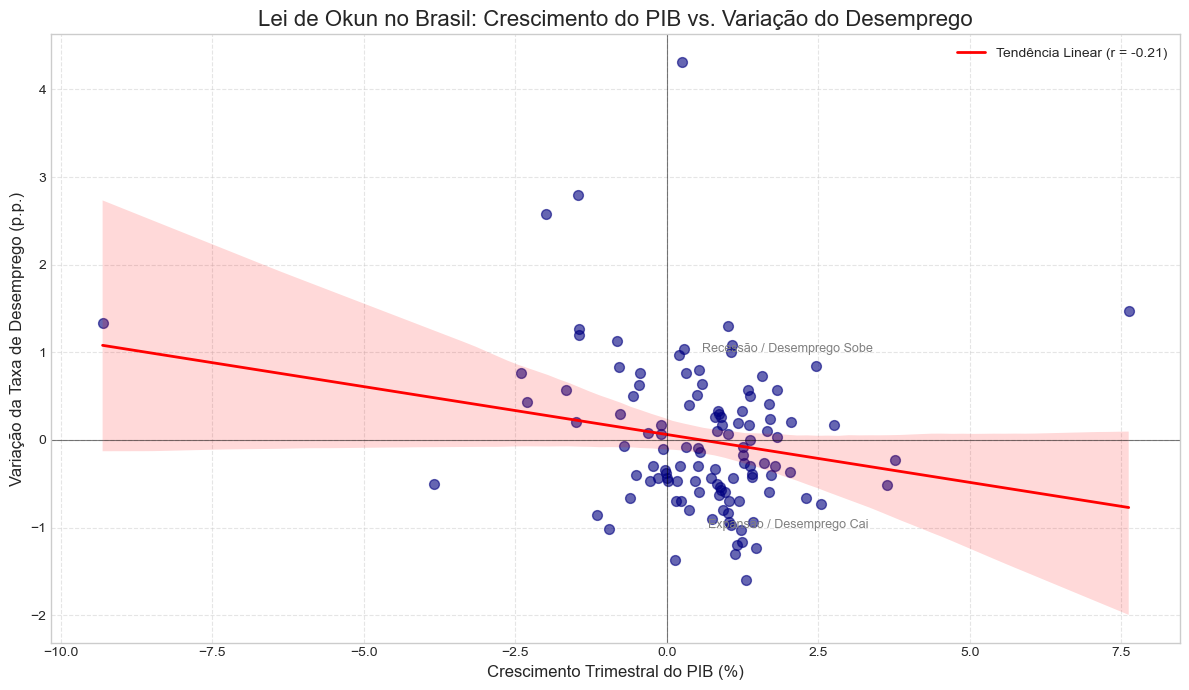

=> Figura salva: fig_03_scatter_okun_lag0.png

--- Interpretação Preliminar ---
Resultado: Correlação NEGATIVA.
Isso confirma visualmente a Lei de Okun: quando o PIB cresce, o desemprego tende a cair.
A relação linear aparenta ser MODERADA ou FRACA (outros fatores podem influenciar).


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# --- 1.4 Análise de Correlação (Exploratória) ---

# Certificando-se de usar o dataframe ajustado (sem NaNs e no período correto)
# Se você rodou as células anteriores, 'df_final_ajustado' já deve estar na memória.
if 'df_final_ajustado' not in locals():
    print("Aviso: 'df_final_ajustado' não encontrado. Usando 'df_final' (certifique-se de que não há NaNs).")
    df_analise = df_final.dropna()
else:
    df_analise = df_final_ajustado

print("="*60)
print("1.4 Análise de Correlação: Lei de Okun (Visualização)")
print("="*60)

# 1. Cálculo da Correlação de Pearson
# Mede a força e a direção da relação linear entre as duas variáveis estacionárias
correlacao_matrix = df_analise[['crescimento_pib', 'delta_u_t']].corr(method='pearson')
r_pearson = correlacao_matrix.loc['crescimento_pib', 'delta_u_t']

print(f"\nMatriz de Correlação:\n{correlacao_matrix}")
print(f"\nCoeficiente de Correlação de Pearson (r): {r_pearson:.4f}")


# 2. Gráfico de Dispersão (Scatter Plot) com Linha de Regressão
plt.figure(figsize=(12, 7))

# Usando seaborn para facilitar a plotagem da linha de regressão e intervalo de confiança
sns.regplot(
    x='crescimento_pib', 
    y='delta_u_t', 
    data=df_analise, 
    scatter_kws={'alpha': 0.6, 'color': 'navy', 's': 50}, 
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Tendência Linear (r = {r_pearson:.2f})'}
)

# Melhorias visuais
plt.title('Lei de Okun no Brasil: Crescimento do PIB vs. Variação do Desemprego', fontsize=16)
plt.xlabel('Crescimento Trimestral do PIB (%)', fontsize=12)
plt.ylabel('Variação da Taxa de Desemprego (p.p.)', fontsize=12)

# Linhas de referência nos eixos 0
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Quadrantes de interpretação (opcional, para didática)
plt.text(2, 1, 'Recessão / Desemprego Sobe', fontsize=9, color='gray', ha='center')
plt.text(2, -1, 'Expansão / Desemprego Cai', fontsize=9, color='gray', ha='center')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../figuras/fase1_tratamento/fig_03_scatter_okun_lag0.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_03_scatter_okun_lag0.png')
# 3. Interpretação Automática
print("\n--- Interpretação Preliminar ---")
if r_pearson < 0:
    print("Resultado: Correlação NEGATIVA.")
    print("Isso confirma visualmente a Lei de Okun: quando o PIB cresce, o desemprego tende a cair.")
    if abs(r_pearson) > 0.5:
        print("A relação linear aparenta ser FORTE.")
    else:
        print("A relação linear aparenta ser MODERADA ou FRACA (outros fatores podem influenciar).")
else:
    print("Resultado: Correlação POSITIVA ou NULA (Inesperado para a Lei de Okun).")


1.4.1 Investigação de Defasagens: Correlação Cruzada (PIB vs Desemprego)

Calculando correlação entre Variação do Desemprego (t) e Crescimento do PIB (t-k):
Lag 0 (PIB de 0 trimestres atrás): -0.2079
Lag 1 (PIB de 1 trimestres atrás): -0.2615
Lag 2 (PIB de 2 trimestres atrás): -0.1114
Lag 3 (PIB de 3 trimestres atrás): -0.0903
Lag 4 (PIB de 4 trimestres atrás): -0.1907
Lag 5 (PIB de 5 trimestres atrás): -0.0788
Lag 6 (PIB de 6 trimestres atrás): 0.1077
Lag 7 (PIB de 7 trimestres atrás): 0.0010
Lag 8 (PIB de 8 trimestres atrás): 0.0750


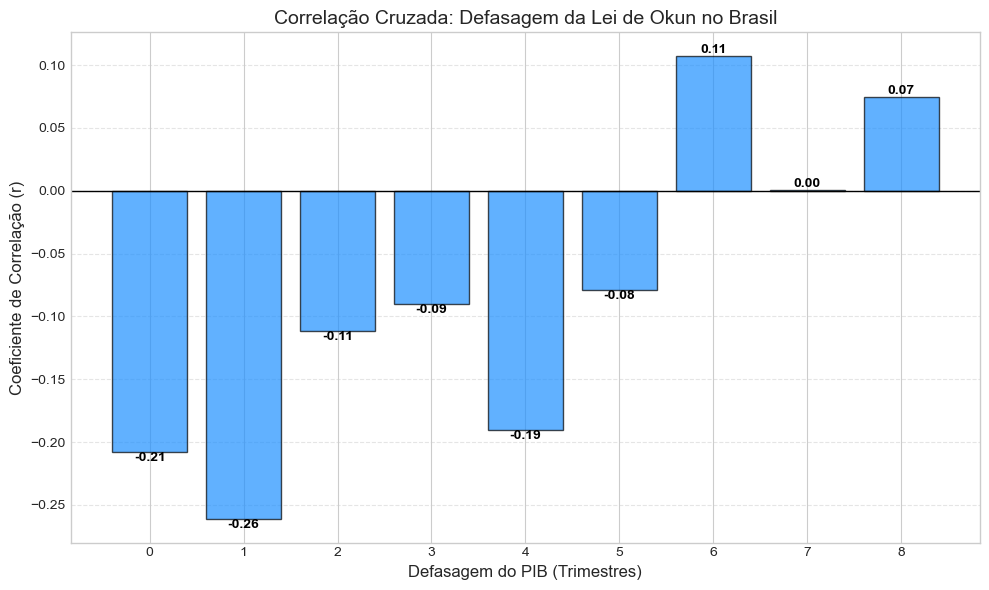

=> Figura salva: fig_04_correlacao_cruzada.png

--- Interpretação dos Resultados ---
A correlação mais forte (-0.2615) ocorre no LAG 1.
Isso indica que mudanças no PIB levam cerca de 1 trimestres (3 meses)
para impactar com força máxima a taxa de desemprego.


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1.4.1 Investigação de Defasagens (Correlação Cruzada) ---

# Certificando-se de usar o dataframe correto (sem NaNs)
if 'df_final_ajustado' in locals():
    df_analise = df_final_ajustado.copy()
else:
    # Caso a célula de ajuste de período não tenha sido rodada, usa o df_final limpo
    df_analise = df_final.dropna().copy()

print("="*60)
print("1.4.1 Investigação de Defasagens: Correlação Cruzada (PIB vs Desemprego)")
print("="*60)

# Definir o número de lags (trimestres) para analisar
# Vamos olhar para trás: como o PIB de hoje, ontem, anteontem afeta o desemprego de hoje?
# Testaremos até 8 trimestres (2 anos)
lags = range(0, 9)
correlacoes = []

print(f"\nCalculando correlação entre Variação do Desemprego (t) e Crescimento do PIB (t-k):")

for k in lags:
    # .shift(k) move os valores do PIB para o futuro no dataframe, 
    # o que alinha o PIB de 'k' períodos atrás com o Desemprego atual.
    corr = df_analise['delta_u_t'].corr(df_analise['crescimento_pib'].shift(k))
    correlacoes.append(corr)
    print(f"Lag {k} (PIB de {k} trimestres atrás): {corr:.4f}")

# --- Visualização Gráfica (Correlograma) ---
plt.figure(figsize=(10, 6))

# Gráfico de barras para facilitar a comparação da força da correlação
bars = plt.bar(lags, correlacoes, color='dodgerblue', alpha=0.7, edgecolor='black')

# Linha de zero para referência
plt.axhline(0, color='black', linewidth=1)

# Estilização
plt.title('Correlação Cruzada: Defasagem da Lei de Okun no Brasil', fontsize=14)
plt.xlabel('Defasagem do PIB (Trimestres)', fontsize=12)
plt.ylabel('Coeficiente de Correlação (r)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(lags)

# Adicionar os valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom' if height > 0 else 'top', 
             fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../figuras/fase1_tratamento/fig_04_correlacao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_04_correlacao_cruzada.png')
# --- Interpretação Automática ---
print("\n--- Interpretação dos Resultados ---")
# Encontrar o lag com a correlação mais forte (mais negativa, pois a relação é inversa)
min_corr = min(correlacoes)
best_lag = lags[correlacoes.index(min_corr)]

if abs(min_corr) < 0.2:
    print("A correlação apresenta-se fraca em todos os lags analisados.")
else:
    print(f"A correlação mais forte ({min_corr:.4f}) ocorre no LAG {best_lag}.")
    if best_lag == 0:
        print("O efeito é imediato (contemporâneo).")
    else:
        print(f"Isso indica que mudanças no PIB levam cerca de {best_lag} trimestres ({best_lag*3} meses)")
        print("para impactar com força máxima a taxa de desemprego.")


Correlação: Variação do Desemprego (t) vs Crescimento do PIB (t-1)
Coeficiente de Correlação de Pearson (r): -0.2615
P-valor: 0.0050
Conclusão: A correlação é estatisticamente significante a 5% de confiança.


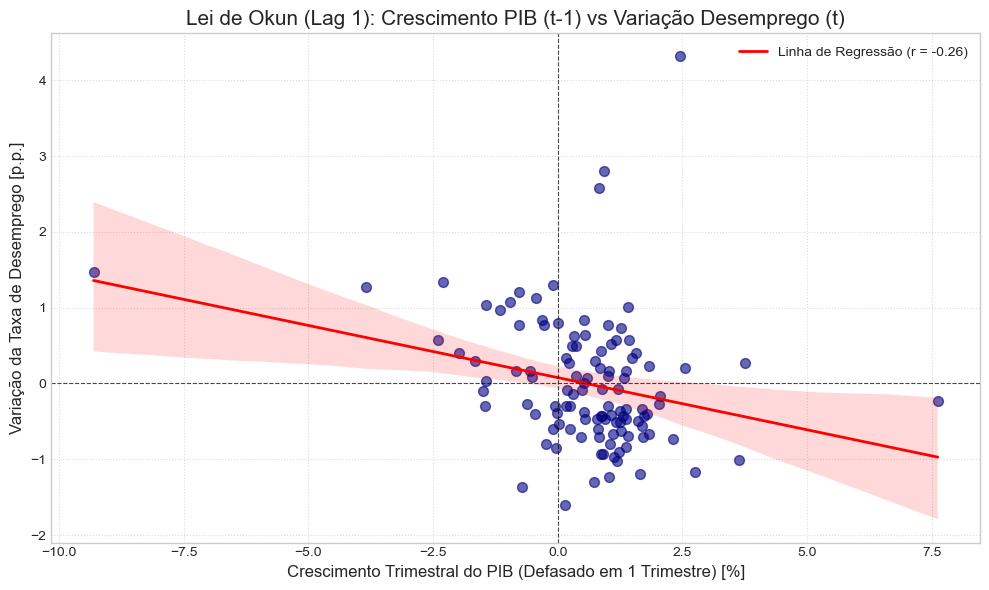

=> Figura salva: fig_05_scatter_okun_lag1.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. Preparação dos dados com Lag 1 ---
# Faremos uma cópia para não alterar o DataFrame original
df_lag1 = df_final_ajustado[['delta_u_t', 'crescimento_pib']].copy()

# Criar a coluna com o lag 1 (deslocar o crescimento do PIB 1 trimestre para frente)
df_lag1['crescimento_pib_lag1'] = df_lag1['crescimento_pib'].shift(1)

# O .shift(1) gera um NaN na primeira linha, então precisamos removê-lo
df_lag1 = df_lag1.dropna()

# --- 2. Cálculo da Correlação de Pearson e P-valor ---
r_pearson, p_valor = pearsonr(df_lag1['crescimento_pib_lag1'], df_lag1['delta_u_t'])

print("="*65)
print("Correlação: Variação do Desemprego (t) vs Crescimento do PIB (t-1)")
print("="*65)
print(f"Coeficiente de Correlação de Pearson (r): {r_pearson:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("Conclusão: A correlação é estatisticamente significante a 5% de confiança.")
else:
    print("Conclusão: A correlação NÃO é estatisticamente significante a 5% de confiança.")

# --- 3. Visualização (Gráfico de Dispersão com Regressão Linear) ---
plt.figure(figsize=(10, 6))

sns.regplot(
    x='crescimento_pib_lag1', 
    y='delta_u_t', 
    data=df_lag1, 
    scatter_kws={'alpha': 0.6, 'color': 'navy', 's': 50}, 
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Linha de Regressão (r = {r_pearson:.2f})'}
)

plt.title('Lei de Okun (Lag 1): Crescimento PIB (t-1) vs Variação Desemprego (t)', fontsize=15)
plt.xlabel('Crescimento Trimestral do PIB (Defasado em 1 Trimestre) [%]', fontsize=12)
plt.ylabel('Variação da Taxa de Desemprego [p.p.]', fontsize=12)

# Adiciona linhas de referência nos eixos zero
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('../figuras/fase1_tratamento/fig_05_scatter_okun_lag1.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_05_scatter_okun_lag1.png')


In [12]:
# A variável 'df_final_ajustado' já deve existir da célula anterior.
# Vamos usar as duas colunas estacionárias para o teste.
from statsmodels.tsa.stattools import grangercausalitytests
data_para_teste = df_final_ajustado[['delta_u_t', 'crescimento_pib']].copy()

print("--- Teste de Causalidade de Granger ---")
print(f"Testando com até 4 trimestres de defasagem (lags).\n")
print("A Hipótese Nula (H₀) é que a série X NÃO causa (no sentido de Granger) a série Y.")
print("Um p-valor < 0.05 nos leva a rejeitar a H₀, indicando que há causalidade de Granger.\n")

# --- Teste 1: Crescimento do PIB -> Variação do Desemprego ---
# H₀: 'crescimento_pib' NÃO causa 'delta_u_t'
print("="*50)
print("Teste 1: O crescimento do PIB causa a variação do desemprego?")
print("H₀: crescimento_pib não causa delta_u_t")
print("="*50)
# A função espera que a primeira coluna seja a variável 'causada' (Y)
# e a segunda seja a variável 'causadora' (X).
resultado_1 = grangercausalitytests(data_para_teste[['delta_u_t', 'crescimento_pib']], maxlag=4, verbose=True)


# --- Teste 2: Variação do Desemprego -> Crescimento do PIB ---
# H₀: 'delta_u_t' NÃO causa 'crescimento_pib'
print("\n\n" + "="*50)
print("Teste 2: A variação do desemprego causa o crescimento do PIB?")
print("H₀: delta_u_t não causa crescimento_pib")
print("="*50)
resultado_2 = grangercausalitytests(data_para_teste[['crescimento_pib', 'delta_u_t']], maxlag=4, verbose=True)

--- Teste de Causalidade de Granger ---
Testando com até 4 trimestres de defasagem (lags).

A Hipótese Nula (H₀) é que a série X NÃO causa (no sentido de Granger) a série Y.
Um p-valor < 0.05 nos leva a rejeitar a H₀, indicando que há causalidade de Granger.

Teste 1: O crescimento do PIB causa a variação do desemprego?
H₀: crescimento_pib não causa delta_u_t

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.8811  , p=0.0099  , df_denom=111, df_num=1
ssr based chi2 test:   chi2=7.0670  , p=0.0079  , df=1
likelihood ratio test: chi2=6.8567  , p=0.0088  , df=1
parameter F test:         F=6.8811  , p=0.0099  , df_denom=111, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.6343  , p=0.0297  , df_denom=108, df_num=2
ssr based chi2 test:   chi2=7.6050  , p=0.0223  , df=2
likelihood ratio test: chi2=7.3600  , p=0.0252  , df=2
parameter F test:         F=3.6343  , p=0.0297  , df_denom=108, df_num=2

Granger Causality
number of lags 

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [13]:
from statsmodels.tsa.api import VAR

# --- 1.4.2 Seleção Formal de Defasagens (AIC/BIC) ---

# Usar o dataframe ajustado (sem NaNs e no período correto)
if 'df_final_ajustado' in locals():
    df_lags = df_final_ajustado[['delta_u_t', 'crescimento_pib']]
else:
    # Fallback caso a célula anterior não tenha sido rodada
    df_lags = df_final.dropna()[['delta_u_t', 'crescimento_pib']]

print("="*60)
print("1.4.2 Seleção de Defasagens (Lags) via Critérios de Informação")
print("="*60)

# Ajustar um modelo VAR (Vetores Autorregressivos) apenas para seleção de ordem
model_var = VAR(df_lags)

# Testar até 8 trimestres (2 anos) de defasagem
# O método select_order calcula AIC, BIC, FPE e HQIC para cada lag automaticamente
lag_results = model_var.select_order(maxlags=8)

print("\n--- Resumo dos Critérios de Informação ---")
print(lag_results.summary())

print("\n--- Defasagens Ótimas Sugeridas ---")
print(f"AIC (Akaike): {lag_results.aic}")
print(f"BIC (Bayesian/Schwarz): {lag_results.bic}")
print(f"FPE (Final Prediction Error): {lag_results.fpe}")
print(f"HQIC (Hannan-Quinn): {lag_results.hqic}")

print("\n--- Conclusão para Modelagem ---")
print(f"Recomendação: Utilizar Lag {lag_results.aic} (se foco em previsão/AIC) ou Lag {lag_results.bic} (se foco em parcimônia/BIC).")
print("Este valor deve ser usado no Teste de Granger abaixo e nos modelos de regressão.")


1.4.2 Seleção de Defasagens (Lags) via Critérios de Informação

--- Resumo dos Critérios de Informação ---
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      0.6108     0.6607*       1.842      0.6310
1      0.5924      0.7422       1.808      0.6531
2      0.5886      0.8384       1.802      0.6899
3      0.6244      0.9741       1.868      0.7661
4      0.3866      0.8363       1.473     0.5689*
5      0.3796      0.9292       1.464      0.6024
6     0.3689*       1.018      1.450*      0.6322
7      0.4069       1.156       1.508      0.7107
8      0.4153       1.265       1.523      0.7596
-------------------------------------------------

--- Defasagens Ótimas Sugeridas ---
AIC (Akaike): 6
BIC (Bayesian/Schwarz): 0
FPE (Final Prediction Error): 6
HQIC (Hannan-Quinn): 4

--- Conclusão para Modelagem ---
Recomendação: Utilizar Lag 6 (se foco em previsão/AIC) ou Lag 0 (se foco em

In [14]:
import statsmodels.formula.api as smf
from scipy import stats
import pandas as pd

# --- 1.7 Teste de Quebra Estrutural (Teste de Chow) ---

# 1. Preparar os dados com a defasagem escolhida (Lag 1)
# Verificando se o dataframe ajustado já existe
if 'df_final_ajustado' in locals():
    df_chow = df_final_ajustado[['delta_u_t', 'crescimento_pib']].copy()
else:
    df_chow = df_final.dropna()[['delta_u_t', 'crescimento_pib']].copy()

# Criar a variável defasada
df_chow['crescimento_pib_lag1'] = df_chow['crescimento_pib'].shift(1)
df_chow = df_chow.dropna()

def chow_test(df, formula, break_date):
    """
    Executa o Teste de Chow para verificar a estabilidade dos parâmetros
    antes e depois de uma data específica (quebra estrutural).
    """
    # Dividir a amostra
    df_before = df[df.index < break_date]
    df_after = df[df.index >= break_date]
    
    # Se não houver dados suficientes de um lado, retorna nulo
    if len(df_before) < 5 or len(df_after) < 5:
        return None, None
        
    # 1. Modelo Agrupado (Pooled - toda a amostra)
    model_pool = smf.ols(formula, data=df).fit()
    ssr_pool = model_pool.ssr
    k = model_pool.df_model + 1 # Número de parâmetros estimados (incluindo intercepto)
    
    # 2. Modelo Antes da Quebra
    model_before = smf.ols(formula, data=df_before).fit()
    ssr_before = model_before.ssr
    
    # 3. Modelo Depois da Quebra
    model_after = smf.ols(formula, data=df_after).fit()
    ssr_after = model_after.ssr
    
    # Número de observações
    N1 = len(df_before)
    N2 = len(df_after)
    
    # 4. Cálculo da Estatística F de Chow
    numerador = (ssr_pool - (ssr_before + ssr_after)) / k
    denominador = (ssr_before + ssr_after) / (N1 + N2 - 2 * k)
    
    f_stat = numerador / denominador
    
    # 5. P-valor usando a distribuição F
    p_value = stats.f.sf(f_stat, k, N1 + N2 - 2 * k)
    
    return f_stat, p_value

# Datas prováveis dos choques agudos que vimos nos gráficos:
datas_teste = [
    '2008-12-31', # Estouro da crise (Q4 2008)
    '2009-03-31', # Reflexo no Brasil (Q1 2009)
    '2020-03-31', # Início Pandemia (Q1 2020)
    '2020-06-30'  # Auget Pandemia (Q2 2020)
]

formula_okun = 'delta_u_t ~ crescimento_pib_lag1'

print("="*65)
print("1.7 Teste de Chow: Verificação de Choques/Quebras Estruturais")
print("="*65)
print(f"Modelo avaliado: {formula_okun}\n")

for data in datas_teste:
    data_pd = pd.to_datetime(data)
    f_stat, p_valor = chow_test(df_chow, formula_okun, data_pd)
    
    if f_stat is not None:
        print(f"[*] Testando quebra no trimestre: {data}")
        print(f"    Estatística F: {f_stat:.4f} | P-valor: {p_valor:.4f}")
        
        if p_valor < 0.05:
            print("    => Conclusão: REJEITA-SE H0. Há quebra estrutural significativa nesta data!\n")
        else:
            print("    => Conclusão: NÃO REJEITA H0. Os parâmetros do modelo parecem estáveis.\n")


1.7 Teste de Chow: Verificação de Choques/Quebras Estruturais
Modelo avaliado: delta_u_t ~ crescimento_pib_lag1

[*] Testando quebra no trimestre: 2008-12-31
    Estatística F: 0.2788 | P-valor: 0.7572
    => Conclusão: NÃO REJEITA H0. Os parâmetros do modelo parecem estáveis.

[*] Testando quebra no trimestre: 2009-03-31
    Estatística F: 0.2159 | P-valor: 0.8062
    => Conclusão: NÃO REJEITA H0. Os parâmetros do modelo parecem estáveis.

[*] Testando quebra no trimestre: 2020-03-31
    Estatística F: 1.3381 | P-valor: 0.2666
    => Conclusão: NÃO REJEITA H0. Os parâmetros do modelo parecem estáveis.

[*] Testando quebra no trimestre: 2020-06-30
    Estatística F: 1.6151 | P-valor: 0.2035
    => Conclusão: NÃO REJEITA H0. Os parâmetros do modelo parecem estáveis.



Datas dos Outliers Identificados (Afastados da Tendência)
Data: 1998-T1 | Cresc. PIB (Lag1):   0.84% | Variação Desemprego:  2.57 p.p. | Distância (Z):  3.14
Data: 2002-T2 | Cresc. PIB (Lag1):   2.46% | Variação Desemprego:  4.31 p.p. | Distância (Z):  5.53
Data: 2012-T1 | Cresc. PIB (Lag1):   0.93% | Variação Desemprego:  2.80 p.p. | Distância (Z):  3.43


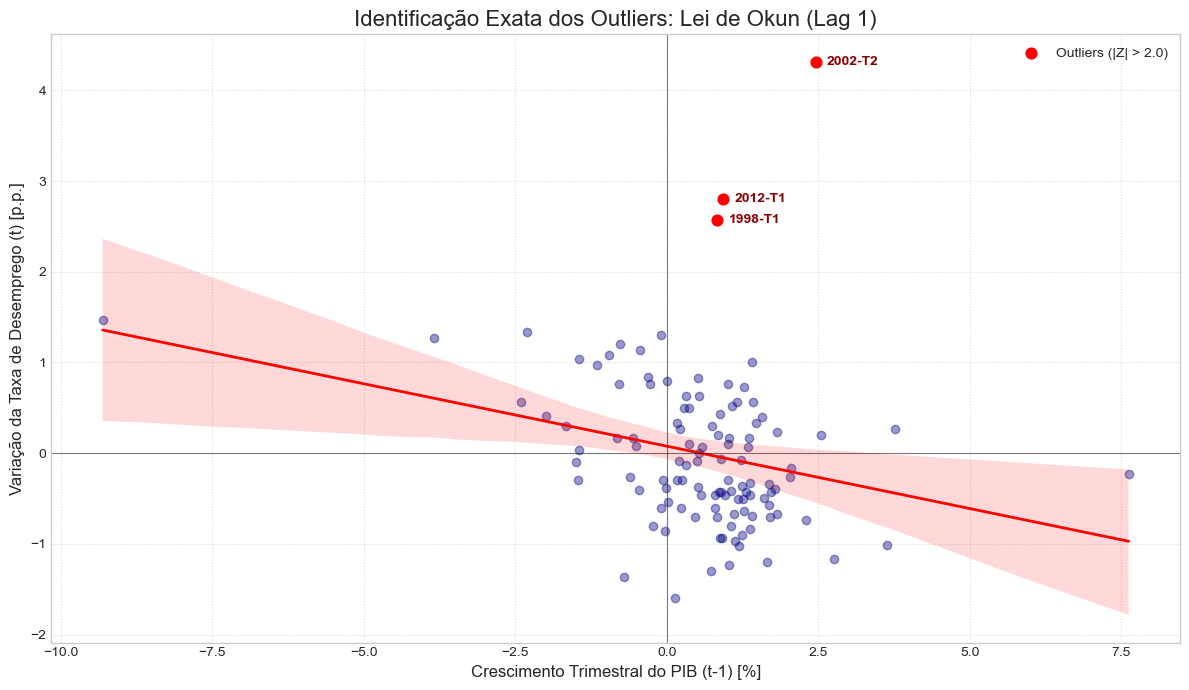

=> Figura salva: fig_06_outliers_identificados.png


In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1.8 Identificação Analítica de Outliers (Lag 1) ---

# Prepara os dados (Lag 1)
df_outliers = df_final_ajustado[['delta_u_t', 'crescimento_pib']].copy()
df_outliers['crescimento_pib_lag1'] = df_outliers['crescimento_pib'].shift(1)
df_outliers = df_outliers.dropna()

# 1. Ajustar a regressão OLS para extrair os resíduos (distância da linha)
X = sm.add_constant(df_outliers['crescimento_pib_lag1'])
Y = df_outliers['delta_u_t']
modelo_outliers = sm.OLS(Y, X).fit()

# 2. Obter a influência e os resíduos padronizados (Studentizados)
influencia = modelo_outliers.get_influence()
# Valores absolutos > 2 indicam pontos que fogem 95% do padrão normal
df_outliers['residuo_pad'] = influencia.resid_studentized_internal

# Definir limite estatístico (2.0 é um bom limite para amostras deste tamanho)
limite = 2.0
outliers_df = df_outliers[df_outliers['residuo_pad'].abs() > limite]

print("="*65)
print("Datas dos Outliers Identificados (Afastados da Tendência)")
print("="*65)

# Listar os outliers no console
for data, row in outliers_df.iterrows():
    trimestre = f"{data.year}-T{data.quarter}"
    print(f"Data: {trimestre} | Cresc. PIB (Lag1): {row['crescimento_pib_lag1']:>6.2f}% | Variação Desemprego: {row['delta_u_t']:>5.2f} p.p. | Distância (Z): {row['residuo_pad']:>5.2f}")

# 3. Gerar o gráfico com anotações
plt.figure(figsize=(12, 7))

# Gráfico base
sns.regplot(
    x='crescimento_pib_lag1', 
    y='delta_u_t', 
    data=df_outliers, 
    scatter_kws={'alpha': 0.4, 'color': 'navy'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

# Destacar os outliers
plt.scatter(outliers_df['crescimento_pib_lag1'], outliers_df['delta_u_t'], color='red', s=60, label=f'Outliers (|Z| > {limite})', zorder=5)

# Anotar o trimestre/ano ao lado de cada outlier
for data, row in outliers_df.iterrows():
    trimestre_label = f"{data.year}-T{data.quarter}"
    plt.annotate(
        trimestre_label,
        (row['crescimento_pib_lag1'], row['delta_u_t']),
        textcoords="offset points", 
        xytext=(8, 0), # Desloca o texto um pouco para a direita
        ha='left', va='center', 
        fontsize=10, color='darkred', fontweight='bold'
    )

plt.title('Identificação Exata dos Outliers: Lei de Okun (Lag 1)', fontsize=16)
plt.xlabel('Crescimento Trimestral do PIB (t-1) [%]', fontsize=12)
plt.ylabel('Variação da Taxa de Desemprego (t) [p.p.]', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('../figuras/fase1_tratamento/fig_06_outliers_identificados.png', dpi=150, bbox_inches='tight')
plt.show()
print('=> Figura salva: fig_06_outliers_identificados.png')


In [16]:
import pandas as pd

# --- 1.8.1 Teste de Chow nas Datas Exatas dos Outliers ---

# IMPORTANTE: Substitua as datas abaixo pelas datas EXATAS que foram 
# impressas no console na etapa anterior (Identificação de Outliers)
# Exemplo: se o outlier foi no 2º trimestre de 2020, use '2020-06-30'
datas_outliers = [
    '2012-T1 ',
    '2002-T2',
    '1998-T1'
    # Adicione mais datas se houver...
]

print("="*65)
print("Teste de Chow: Verificação das Datas dos Outliers (Z > 2.0)")
print("="*65)

# A função chow_test e o df_chow já devem estar na memória (da seção 1.7)
for data_str in datas_outliers:
    if 'COLOQUE' in data_str:
        print("-> ATENÇÃO: Por favor, preencha a lista 'datas_outliers' no código com as datas encontradas.")
        break
        
    data_pd = pd.to_datetime(data_str)
    
    # Chama a função definida anteriormente
    f_stat, p_valor = chow_test(df_chow, formula_okun, data_pd)
    
    if f_stat is not None:
        print(f"[*] Testando quebra no trimestre do Outlier: {data_str}")
        print(f"    Estatística F: {f_stat:.4f} | P-valor: {p_valor:.4f}")
        
        if p_valor < 0.05:
            print("    => Conclusão: REJEITA-SE H0. Confirmada a quebra estrutural severa nesta data!\n")
        else:
            print("    => Conclusão: NÃO REJEITA H0. O outlier não gerou quebra estrutural significativa.\n")


Teste de Chow: Verificação das Datas dos Outliers (Z > 2.0)
[*] Testando quebra no trimestre do Outlier: 2012-T1 
    Estatística F: 0.0529 | P-valor: 0.9485
    => Conclusão: NÃO REJEITA H0. O outlier não gerou quebra estrutural significativa.

[*] Testando quebra no trimestre do Outlier: 2002-T2
    Estatística F: 0.2833 | P-valor: 0.7538
    => Conclusão: NÃO REJEITA H0. O outlier não gerou quebra estrutural significativa.

[*] Testando quebra no trimestre do Outlier: 1998-T1
    Estatística F: 0.7525 | P-valor: 0.4736
    => Conclusão: NÃO REJEITA H0. O outlier não gerou quebra estrutural significativa.

